In [4]:
import pandas as pd

# Load the raw data in project
health_data = pd.read_csv("C:\\Users\\user\\anaconda_projects\\Data Analysis of Health Care\\Health_dataset.csv")
print(health_data.head())

  Patient ID  Gender       Disease         Treatment               Hospital  \
0  PAT-00001    Male  Tuberculosis          Dialysis  City General Hospital   
1  PAT-00002  Female       Malaria          Dialysis  City General Hospital   
2  PAT-00003  Female       Malaria           Surgery  City General Hospital   
3  PAT-00004    Male        Asthma          Dialysis  City General Hospital   
4  PAT-00005  Female      Diabetes  Physical Therapy  City General Hospital   

  Admission Date Discharge Date Treatment Status Cause of Death Date of Birth  
0     2022-12-19     2023-01-16        Recovered            NaN    1973-06-05  
1     2023-03-29     2023-04-21        Recovered            NaN    1998-11-21  
2     2022-09-16     2022-10-15        Recovered            NaN    1942-02-14  
3     2022-02-07     2022-02-11        Recovered            NaN    1943-01-17  
4     2022-10-25     2022-10-30        Recovered            NaN    1979-07-28  


In [11]:
# Retrieve patient age groups by total number of patient visits

# Convert the admission date and Date of Birth to date format
health_data['Admission Date'] = pd.to_datetime(health_data['Admission Date'])
health_data['Date of Birth'] = pd.to_datetime(health_data['Date of Birth'])

# Calculate the patients age at the time of Admission 
health_data['Age'] = (health_data['Admission Date']- health_data['Date of Birth']).dt.days / 365.25
health_data['Age'] = health_data['Age'].astype(int)


print(health_data['Age'])

0       49
1       24
2       80
3       79
4       43
        ..
7995    96
7996    17
7997    28
7998    24
7999    91
Name: Age, Length: 8000, dtype: int64


In [16]:
# Define age 
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '21-40', '41-60', '61-80', '81-100'] 

health_data['Age Group'] = pd.cut(health_data['Age'], bins = bins, labels = labels, right=False)


0        41-60
1        21-40
2       81-100
3        61-80
4        41-60
         ...  
7995    81-100
7996      0-20
7997     21-40
7998     21-40
7999    81-100
Name: Age Group, Length: 8000, dtype: category
Categories (5, object): ['0-20' < '21-40' < '41-60' < '61-80' < '81-100']


In [18]:
# Count the number of patients in each Age Group
age_count = health_data['Age Group'].value_counts()

print(age_count)

Age Group
21-40     1646
41-60     1608
81-100    1603
61-80     1580
0-20      1533
Name: count, dtype: int64


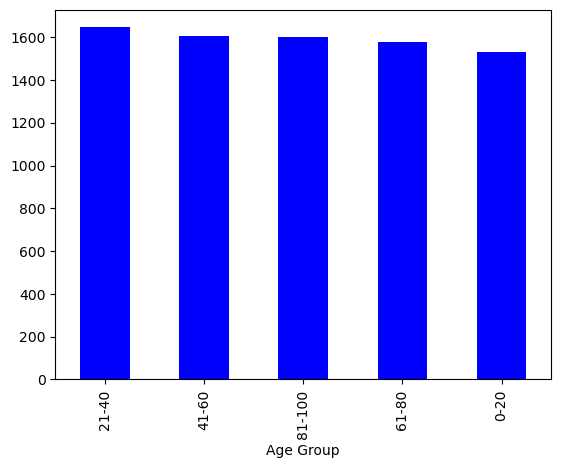

In [20]:
# Visualize the Age Group
ax = age_count.plot(kind= 'bar', color= 'blue')